In [9]:
from sldl import SignLanguageDataset
from sldl.targets.frame_labels import FrameLabelsTarget
from sldl.targets.segments import SegmentTarget

from sign_language_tools.player import VideoPlayer
from sign_language_tools.pose.mediapipe.edges import UPPER_POSE_EDGES, HAND_EDGES

import matplotlib.pyplot as plt
from sign_language_tools.annotations.visualization.timeline import plot_segments_on_timeline

In [2]:
root = "F:/datasets/sign-language/lsfb-cont"
shards_url = f"{root}/shards/annotated/shard_{{000000..000001}}.tar"

In [3]:
dataset = SignLanguageDataset(
    shards_url=shards_url,
    use_windows=True,
    window_size=3500,
    window_stride=2800,
    max_empty_windows=0,
    targets={
        'per-frame-labels': FrameLabelsTarget(),
        'segments': SegmentTarget(),
    },
    precompute_targets=True,
    load_videos=True,
    video_path=f"{root}/videos.tar",
    video_index_path=f"{root}/videos.tar.index.json",
    show_loading_progress=True,
)

len(dataset)

Loading dataset [file:F:/datasets/sign-language/lsfb-cont/shards/annotated/shard_{000000..000001}.tar]...


Loading samples: 126 samples [00:02, 44.92 samples/s]


Loaded 126 samples.
Building windows of size 3500 with stride 2800...
Converted 126 samples to 970 windowed samples.
Removed 101 empty samples. There are 869 final samples.
Precomputing targets...
Target precomputed.


869

In [5]:
sample = dataset[42]
print("Keys in sample:", list(sample.keys()))
print("ID:", sample['id'])
print(f"Window from {sample['start']}ms to {sample['end']}ms")
print("Window ID:", sample['window_id'])
print("Signer ID:", sample['signer_id'])
print("#Frames:", sample['n_frames'])
print("Pose data:", {body_part: data.shape for body_part, data in sample['poses'].items()})
print("Video data (be careful, it consumes a lot of RAM):", sample['video'].shape)

Keys in sample: ['id', 'signer_id', 'poses', 'annotations', 'n_frames', '__key__', 'start', 'end', 'targets', 'video', 'window_id']
ID: CLSFBI0305A_S007_B
Window from 16800ms to 20300ms
Window ID: CLSFBI0305A_S007_B_16800_20300
Signer ID: S007
#Frames: 3500
Pose data: {'upper_pose': (3500, 23, 3), 'left_hand': (3500, 21, 3), 'right_hand': (3500, 21, 3)}
Video data (be careful, it consumes a lot of RAM): torch.Size([3500, 3, 480, 600])


In [14]:
sample['annotations']['both_hands'].head()

,start_ms,end_ms,gloss,start_frame,end_frame,lemma,sign_type,specifier,variation
170,594,1495,ns:facebook(b-janvier),31,78,facebook,lexical,ns,(b-janvier)
171,1648,2702,ns:facebook(sauna),86,141,facebook,lexical,ns,(sauna)
172,2760,6785,ns:facebook(s-ouvrir),144,354,facebook,lexical,ns,(s-ouvrir)
173,2760,4312,ns:facebook(s-ouvrir),144,225,facebook,lexical,ns,(s-ouvrir)
174,4485,4696,ns:facebook(b-janvier),234,245,facebook,lexical,ns,(b-janvier)


Per frame labels: torch.Size([3500])
Annotations (segments): torch.Size([23, 2])


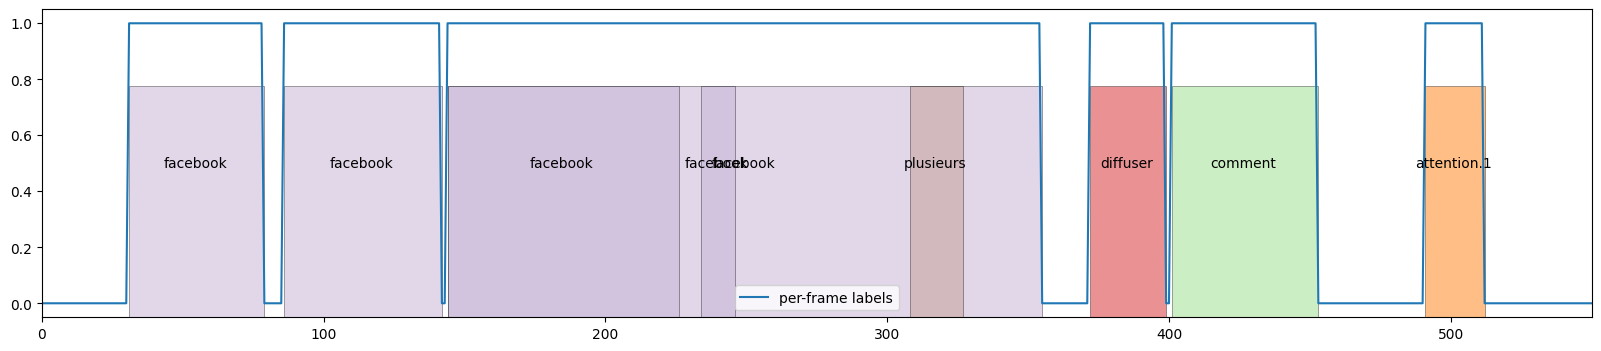

In [19]:
targets = sample['targets']
per_frame_labels = targets['per-frame-labels']
segments = targets['segments']
labels = sample['annotations']['both_hands']['lemma'].to_list()

print("Per frame labels:", per_frame_labels.shape)
print("Annotations (segments):", segments.shape)

plt.figure(figsize=(20, 4))
plt.xlim(0, 550)
plot_segments_on_timeline(segments, y_lim=(0.0, 0.75), labels=labels)
plt.plot(per_frame_labels, label='per-frame labels')
plt.legend()
plt.show()

In [22]:
player = VideoPlayer()
player.attach_video_tensor(sample['video'].permute(0, 2, 3, 1), fps=50, name='video')
player.attach_poses(sample['poses']['upper_pose'], UPPER_POSE_EDGES, parent_name='video')
player.attach_poses(sample['poses']['left_hand'], HAND_EDGES, edge_color=(255, 0, 0), parent_name='video')
player.attach_poses(sample['poses']['right_hand'], HAND_EDGES, edge_color=(0, 0, 255), parent_name='video')
player.attach_segments(segments.numpy(), unit='frame', fps=50, labels=labels, x_lim=(0, 1300), filled=True,
                       background_color=(255, 255, 255), text_color=(0, 0, 0), segment_color=(50, 255, 50),
                       ticks_color=(0, 0, 0))
player.play(speed=0.5)